In [ ]:
#Import

from google.colab import files


uplode = files.upload()

Saving SHOP_2015-05-21_2025-03-16.csv to SHOP_2015-05-21_2025-03-16.csv


Missing values,duplicate handling,data types,standardizing formates,summary statistics,outline detection

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("SHOP_2015-05-21_2025-03-16.csv")

In [ ]:
df.head()

,date,open,high,low,close,adj_close,volume
0,2015-05-21 00:00:00-04:00,2.800,2.874,2.411,2.568,2.568,123039000
1,2015-05-22 00:00:00-04:00,2.607,3.110,2.600,2.831,2.831,28412000
2,2015-05-26 00:00:00-04:00,2.980,3.034,2.908,2.965,2.965,8202000
3,2015-05-27 00:00:00-04:00,3.067,3.081,2.700,2.750,2.750,7976000
4,2015-05-28 00:00:00-04:00,2.755,2.774,2.648,2.745,2.745,4000000


In [ ]:
df.tail()

,date,open,high,low,close,adj_close,volume
2464,2025-03-10 00:00:00-04:00,96.070000,96.186996,91.690002,92.750000,92.750000,16385300
2465,2025-03-11 00:00:00-04:00,92.750000,95.109001,91.150002,92.949997,92.949997,12127100
2466,2025-03-12 00:00:00-04:00,96.669998,99.135002,95.290001,96.529999,96.529999,8531900
2467,2025-03-13 00:00:00-04:00,95.169998,95.529999,89.099998,90.589996,90.589996,11076400
2468,2025-03-14 00:00:00-04:00,94.610001,95.830002,93.059998,94.849998,94.849998,7060700


In [ ]:
df.isnull()

,date,open,high,low,close,adj_close,volume
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
2464,False,False,False,False,False,False,False
2465,False,False,False,False,False,False,False
2466,False,False,False,False,False,False,False
2467,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
date,0
open,0
high,0
low,0
close,0
adj_close,0
volume,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["date"] = pd.to_datetime(df["date"])

/tmp/ipykernel_703/3228555721.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df["date"] = pd.to_datetime(df["date"])


In [ ]:
df = df.sort_values("date")

In [ ]:
df = df.set_index("date")

<Axes: xlabel='date', ylabel='close'>

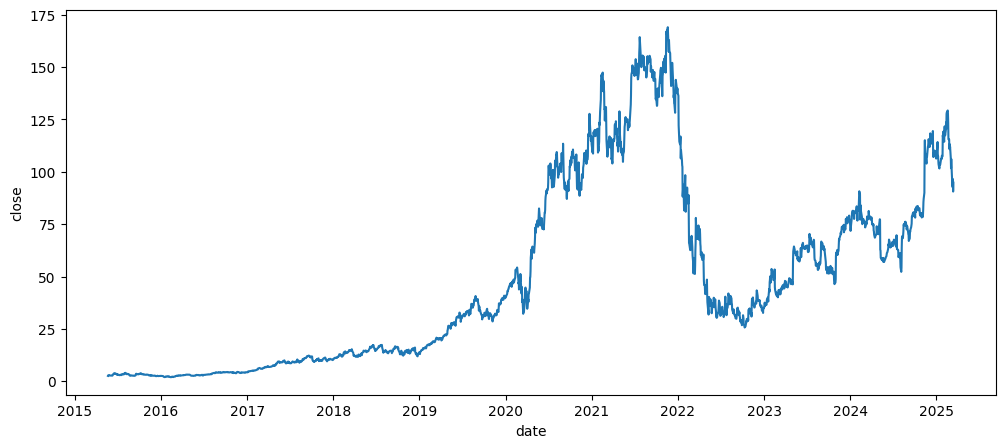

In [ ]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=df,
    x=df.index,
    y="close"
)

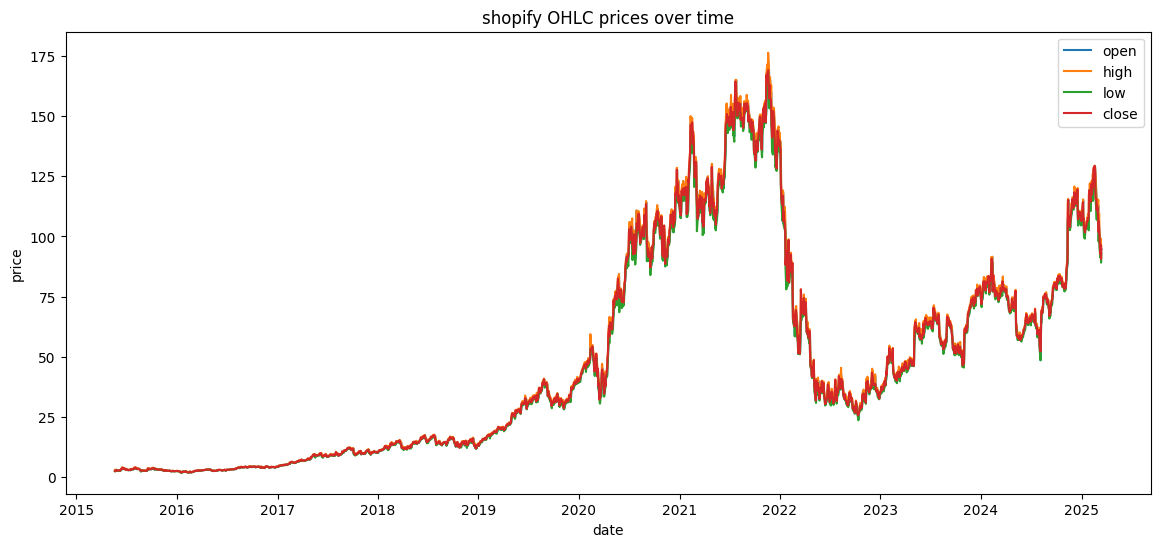

In [ ]:
#visualize OHLC price
plt.figure(figsize=(14,6))

sns.lineplot(data=df,x=df.index,y="open",label="open")
sns.lineplot(data=df,x=df.index,y="high",label="high")
sns.lineplot(data=df,x=df.index,y="low",label="low")
sns.lineplot(data=df,x=df.index,y="close",label="close")

plt.title("shopify OHLC prices over time")
plt.xlabel("date")
plt.ylabel("price")

plt.show()

Text(0, 0.5, 'trading volume')

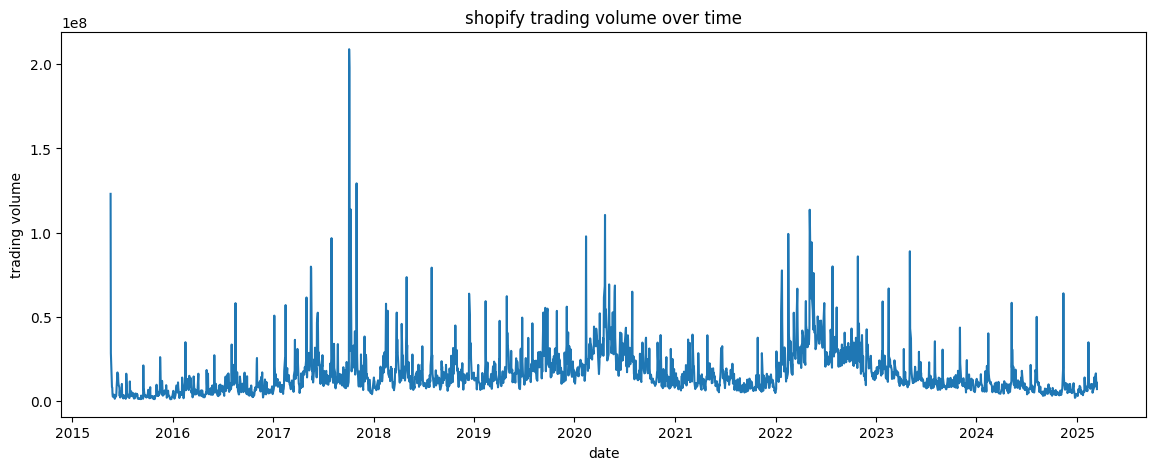

In [ ]:
#visulalizing trading volume over time
plt.figure(figsize=(14,5))
sns.lineplot(
    data=df,
    x="date",
    y="volume"

    )
plt.title("shopify trading volume over time")
plt.xlabel("date")
plt.ylabel("trading volume")

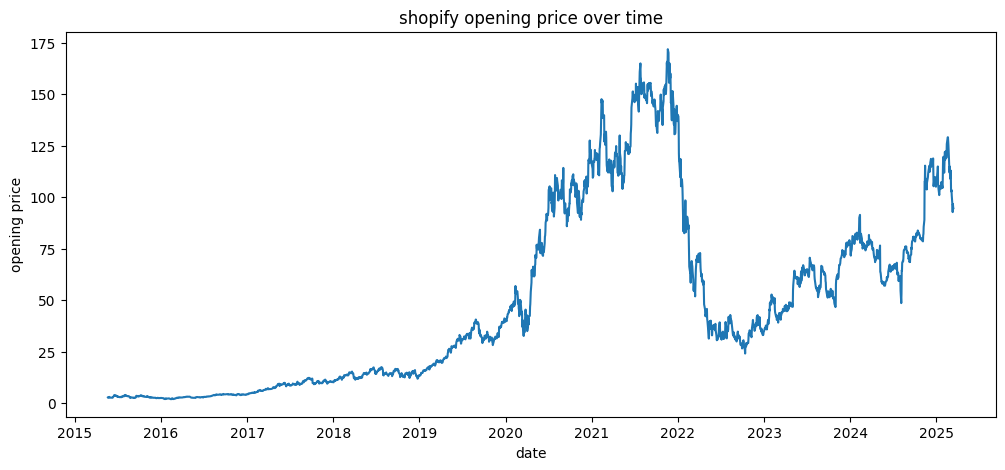

In [ ]:
plt.figure(figsize=(12,5))
sns.lineplot(
    data=df,
    x=df.index,
    y="open"
)
plt.title("shopify opening price over time")
plt.xlabel("date")
plt.ylabel("opening price")

plt.show()

In [ ]:
#Calculate the 20 day SMA


df["SMA_20"] =df["close"].rolling (window=20).mean()
df["SMA_20"]

,SMA_20
date,
2015-05-21 00:00:00-04:00,NaN
2015-05-22 00:00:00-04:00,NaN
2015-05-26 00:00:00-04:00,NaN
2015-05-27 00:00:00-04:00,NaN
2015-05-28 00:00:00-04:00,NaN
...,...
2025-03-10 00:00:00-04:00,114.415001
2025-03-11 00:00:00-04:00,113.067500
2025-03-12 00:00:00-04:00,111.714500


In [ ]:
#Plot Closing Price +20 Day SMA


plt.figure(figure=(14,6))


sns.liqneplot(
    data=df,
    x="date"
    y="closing price"
 )
 sns.li\]

SyntaxError: invalid syntax. Perhaps you forgot a comma? (4191747303.py, line 9)

In [ ]:
df.nlargest(5,"volume")

,open,high,low,close,adj_close,volume,SMA_20
date,,,,,,,
2017-10-04 00:00:00-04:00,11.683,11.693,10.075,10.330,10.330,208959000,11.73800
2017-10-05 00:00:00-04:00,9.753,10.343,9.331,10.043,10.043,197807000,11.67285
2017-10-31 00:00:00-04:00,10.138,10.481,9.451,9.949,9.949,129271000,10.00105
2015-05-21 00:00:00-04:00,2.800,2.874,2.411,2.568,2.568,123039000,NaN
2017-10-10 00:00:00-04:00,9.727,9.900,8.935,9.257,9.257,113732000,11.35170


In [ ]:
df["daily price change"] = df["close"]- df["open"]
df["daily price change"]

,daily price change
date,
2015-05-21 00:00:00-04:00,-0.232000
2015-05-22 00:00:00-04:00,0.224000
2015-05-26 00:00:00-04:00,-0.015000
2015-05-27 00:00:00-04:00,-0.317000
2015-05-28 00:00:00-04:00,-0.010000
...,...
2025-03-10 00:00:00-04:00,-3.320000
2025-03-11 00:00:00-04:00,0.199997
2025-03-12 00:00:00-04:00,-0.139999


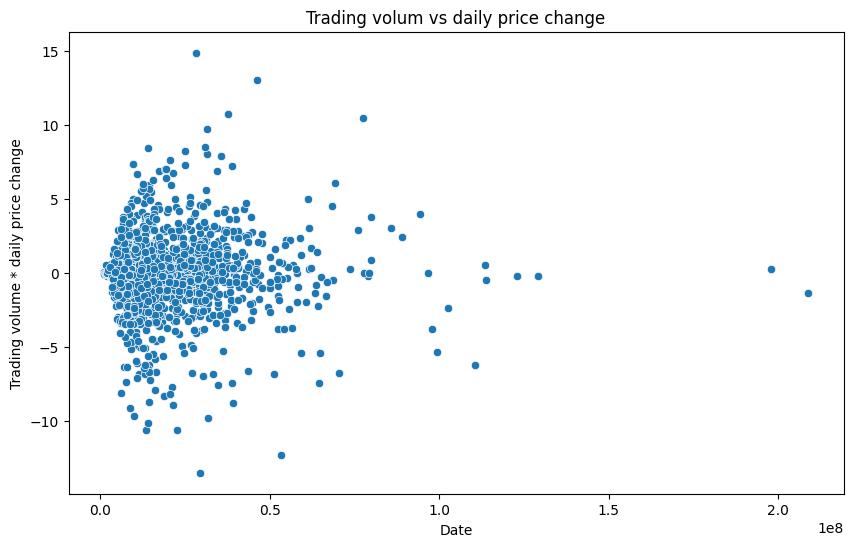

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="volume",
    y="daily price change"
)

plt.title("Trading volum vs daily price change")
plt.xlabel("Date")
plt.ylabel("Trading volume * daily price change")

plt.show()

In [ ]:
df["daily price range"] = df["close"]- df["open"]
df["daily price range"]

,daily price range
date,
2015-05-21 00:00:00-04:00,-0.232000
2015-05-22 00:00:00-04:00,0.224000
2015-05-26 00:00:00-04:00,-0.015000
2015-05-27 00:00:00-04:00,-0.317000
2015-05-28 00:00:00-04:00,-0.010000
...,...
2025-03-10 00:00:00-04:00,-3.320000
2025-03-11 00:00:00-04:00,0.199997
2025-03-12 00:00:00-04:00,-0.139999


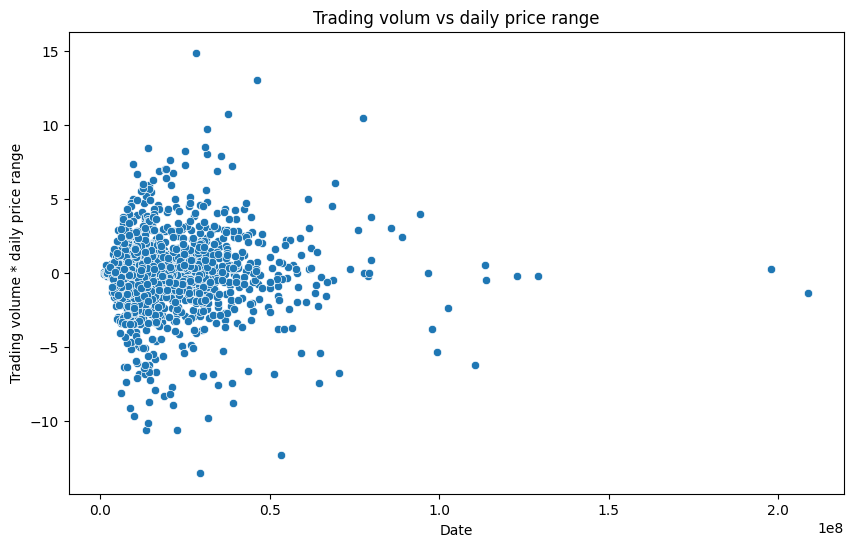

In [ ]:
#volume vs daily price range

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="volume",
    y="daily price range"
)

plt.title("Trading volum vs daily price range")
plt.xlabel("Date")
plt.ylabel("Trading volume * daily price range")

plt.show()

In [ ]:
#calculate the 20 days SMA
df["SMA_20"]=df["close"].rolling(window=20).mean()
df["SMA_20"]

,SMA_20
date,
2015-05-21 00:00:00-04:00,NaN
2015-05-22 00:00:00-04:00,NaN
2015-05-26 00:00:00-04:00,NaN
2015-05-27 00:00:00-04:00,NaN
2015-05-28 00:00:00-04:00,NaN
...,...
2025-03-10 00:00:00-04:00,114.415001
2025-03-11 00:00:00-04:00,113.067500
2025-03-12 00:00:00-04:00,111.714500


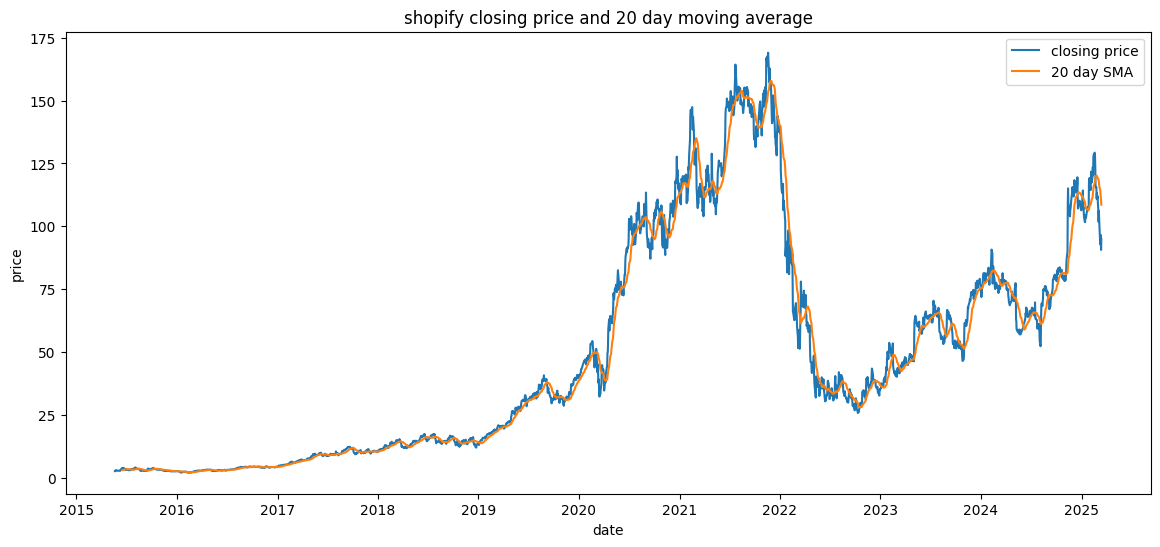

In [ ]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=df,
    x="date",
    y="close",
    label="closing price"
)

sns.lineplot(
    data=df,
    x="date",
    y="SMA_20",
    label="20 day SMA"
)

plt.title("shopify closing price and 20 day moving average")
plt.xlabel("date")
plt.ylabel("price")

plt.show()

ValueError: Could not interpret value `SMA_50` for `y`. An entry with this name does not appear in `data`.

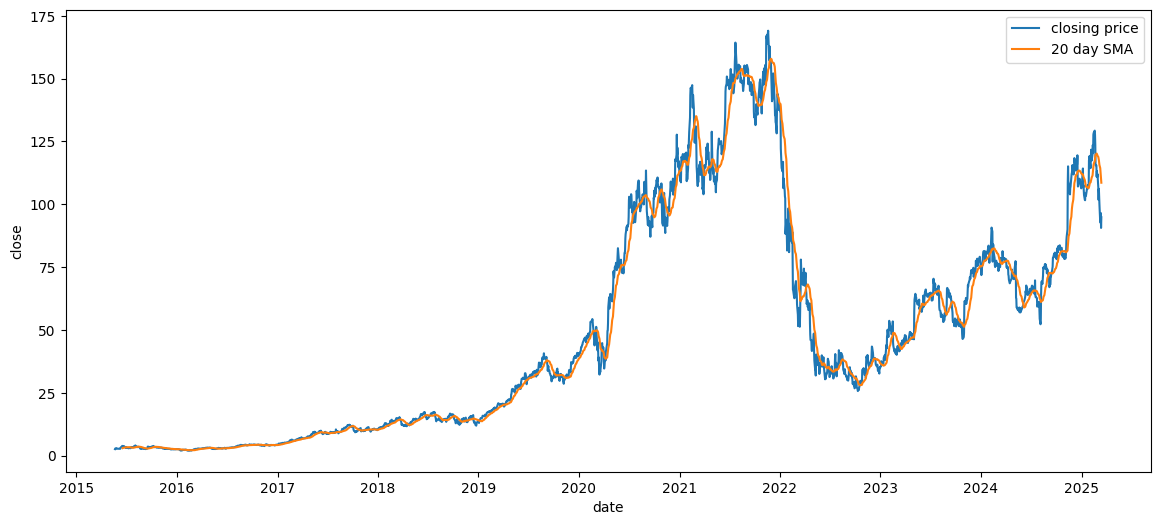

In [ ]:
#plot closing price +50day SMA

plt.figure(figsize=(14,6))

sns.lineplot(
    data=df,
    x="date",
    y="close",
    label="closing price"
)

sns.lineplot(
    data=df,
    x="date",
    y="SMA_20",
    label="20 day SMA"
)

sns.lineplot(
    data=df,
    x="date",
    y="SMA_50",
    label="50 day SMA"
)

plt.title("shopify closing price and 20 day and 50 day moving average")
plt.xlabel("date")
plt.ylabel("price")

plt.show()

In [ ]:
#daily return%

df["daily return%"] = ((df["close"] - df["open"]) / df["open"]) * 100

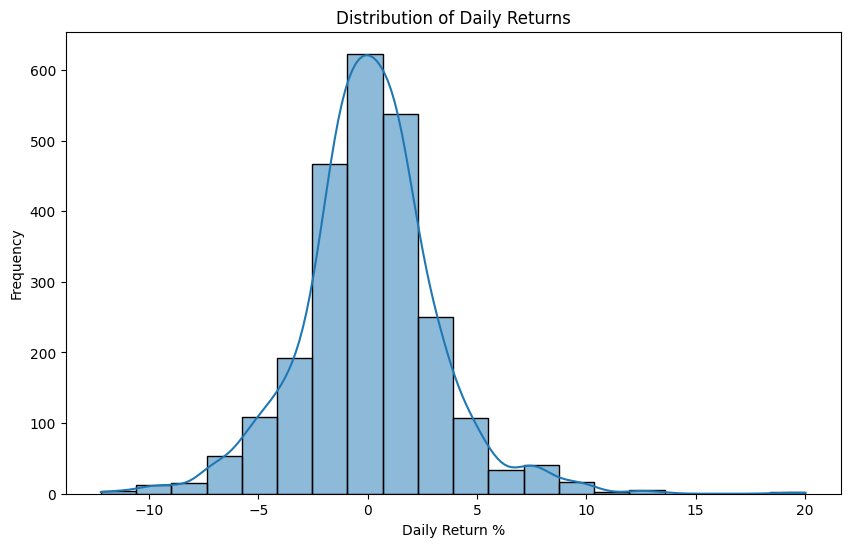

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="daily return%",
    bins=20,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return %")
plt.ylabel("Frequency")

plt.show()

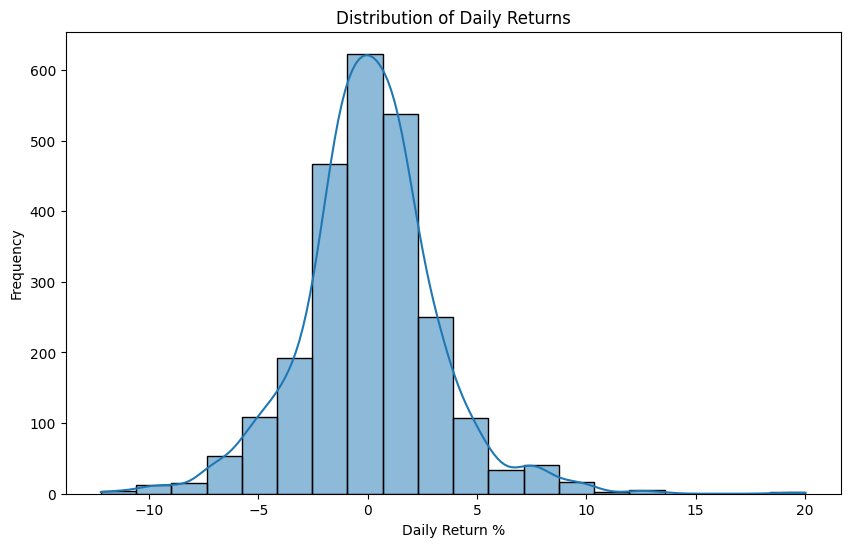

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="daily return%",
    bins=20,
    kde=True #kernal density estimate
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return %")
plt.ylabel("Frequency")

plt.show()

In [ ]:
#volatility

df["Absolute Return"] = df["daily Return %"]

KeyError: 'daily Return %'